# Kinyarwanda Multidomain Domain Classifier

This notebook trains a text classifier for five Kinyarwanda domains:

- Health
- Finance
- Agriculture
- Telecommunications
- Law

A manually annotated Gold Test set is kept completely separate from
training. The classifier is first evaluated on a held-out validation
set and then tested against the human annotations.

The Gold Test set also contains an `others` category for texts that
do not clearly belong to one of the five target domains. Since the
initial classifier is trained only on the five target domains,
`others` examples are analyzed separately.

## Step 2 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 1. Load the required libraries

The classifier uses TF-IDF to convert Kinyarwanda text into numerical
features and Logistic Regression to predict the text domain.

Both word-level and character-level TF-IDF features are used.
Character features are useful for capturing subword patterns and
morphological variation in Kinyarwanda.

## Step 3 — Find your uploaded file paths

In [8]:
import glob

for f in glob.glob("/kaggle/input/**/*", recursive=True):
    if f.endswith((".csv", ".xlsx")):
        print(f)

/kaggle/input/datasets/rose31/whole-dataset/kinyarwanda_multidomain_candidates.csv
/kaggle/input/datasets/rose31/gold-samples/Gold Test sample.xlsx


In [12]:
CORPUS_PATH = "/kaggle/input/datasets/rose31/whole-dataset/kinyarwanda_multidomain_candidates.csv"
GOLD_PATH = "/kaggle/input/datasets/rose31/gold-samples/Gold Test sample.xlsx"

## Step 4 — Load the two datasets

In [13]:
corpus = pd.read_csv(CORPUS_PATH)
gold = pd.read_excel(GOLD_PATH)

print("Full corpus:", corpus.shape)
print("Gold Test:", gold.shape)

display(corpus.head())
display(gold.head())

Full corpus: (50711, 9)
Gold Test: (576, 4)


,id,language,domain,raw_text,source_dataset,source_split,license,review_status,notes
0,kin_health_000001,kin,health,"Ibinini by'umuhondo, umweru w'umutuku ndetse n...",DigitalUmuganda/Afrivoice_Kinyarwanda,train,CC-BY-4.0,unreviewed,Loaded through Professor/kinyarwanda-speech-da...
1,kin_health_000002,kin,health,Icyumba cyo kwa muganga kirimo ibikoresho bige...,DigitalUmuganda/Afrivoice_Kinyarwanda,train,CC-BY-4.0,unreviewed,Loaded through Professor/kinyarwanda-speech-da...
2,kin_health_000003,kin,health,Abaturage bagiye batandukanye bageze mu za buk...,DigitalUmuganda/Afrivoice_Kinyarwanda,train,CC-BY-4.0,unreviewed,Loaded through Professor/kinyarwanda-speech-da...
3,kin_health_000004,kin,health,Abantu benshi bicaye ku ntebe z'urubaho ziri h...,DigitalUmuganda/Afrivoice_Kinyarwanda,train,CC-BY-4.0,unreviewed,Loaded through Professor/kinyarwanda-speech-da...
4,kin_health_000005,kin,health,"Inyubako nini, y'igorofa, isa umuhondo. Imbere...",DigitalUmuganda/Afrivoice_Kinyarwanda,train,CC-BY-4.0,unreviewed,Loaded through Professor/kinyarwanda-speech-da...


,sample_id,raw_text,label,Classifier
0,S0001,Iri ni itsinda ry'abaganga aho bari muri opera...,health,NaN
1,S0002,(i) ubusobanuro ku by'ingenzi biranga serivisi...,law,NaN
2,S0003,"Abantu babiri bambaye imyenda y'imyitozo, umwe...",health,NaN
3,S0004,Ibihingwa ngandubukungu n'ibihingwa nganduraru...,agriculture,NaN
4,S0005,"Ubucuruzi icuruzwamo ikinyobwa cy'amata, umucu...",finance,NaN


## 2. Load the corpus and Gold Test set

The full multidomain corpus provides the training data.

The Gold Test set contains manually reviewed examples and is reserved
for final evaluation. These examples must not appear in the training
or validation data.

## Step 5 — Check your Gold Test

In [14]:
print("Gold Test rows:", len(gold))
print("\nManual labels:")
print(gold["label"].value_counts(dropna=False))

print("\nMissing labels:")
print(gold["label"].isna().sum())

Gold Test rows: 576

Manual labels:
label
law            176
agriculture    102
others         100
health          97
finance         82
telecoms        19
Name: count, dtype: int64

Missing labels:
0


## Step 6 — Remove Gold Test from training

In [15]:
gold_texts = set(
    gold["raw_text"]
    .astype(str)
    .str.strip()
)

training_data = corpus[
    ~corpus["raw_text"]
    .astype(str)
    .str.strip()
    .isin(gold_texts)
].copy()

print("Full corpus:", len(corpus))
print("Training pool:", len(training_data))
print("Gold rows removed:", len(corpus) - len(training_data))

Full corpus: 50711
Training pool: 50135
Gold rows removed: 576


In [16]:
overlap = (
    training_data["raw_text"]
    .astype(str)
    .str.strip()
    .isin(gold_texts)
    .sum()
)

print("Gold Test texts remaining in training:", overlap)

Gold Test texts remaining in training: 0


## 3. Prevent test-set leakage

All 576 manually annotated Gold Test texts are removed from the
training corpus before model development.

This ensures that the final evaluation measures performance on texts
the classifier has never seen during training.

In [17]:
print(training_data["domain"].value_counts())

domain
law            17104
agriculture    11394
finance        10781
health         10613
telecoms         243
Name: count, dtype: int64


## 4. Inspect the training labels

The number of records differs across the five domains. Rather than
discarding large amounts of training data, balanced class weights are
used during Logistic Regression training.

Macro F1 is also reported so that every domain contributes equally to
the evaluation regardless of its number of examples.

## Step 8 — Create train and validation sets

In [18]:
X = training_data["raw_text"].astype(str)
y = training_data["domain"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Validation records:", len(X_val))

print("\nValidation distribution:")
print(y_val.value_counts())

Training records: 40108
Validation records: 10027

Validation distribution:
domain
law            3421
agriculture    2279
finance        2156
health         2123
telecoms         48
Name: count, dtype: int64


## Step 9 — Build the classifier

In [19]:
features = FeatureUnion([
    (
        "word_tfidf",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
            sublinear_tf=True
        )
    ),
    
    (
        "char_tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True
        )
    )
])

model = Pipeline([
    ("features", features),

    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

## 5. Build the classifier

Two TF-IDF representations are combined:

- Word n-grams capture domain-specific words and phrases.
- Character n-grams capture smaller linguistic patterns that may be
  useful for Kinyarwanda morphology.

A Logistic Regression classifier is trained using balanced class
weights to reduce the effect of unequal class sizes.

## Step 10 — Train

In [20]:
model.fit(X_train, y_train)

print("Training complete.")
print(
    "Solver iterations:",
    model.named_steps["classifier"].n_iter_
)

Training complete.
Solver iterations: [77]


## 6. Train the classifier

The Logistic Regression optimizer is allowed a maximum of 2,000
iterations but stops automatically once it converges.

These are optimization iterations rather than deep-learning epochs.

## Step 11 — Overall validation accuracy

In [21]:
val_pred = model.predict(X_val)

val_accuracy = accuracy_score(
    y_val,
    val_pred
)

val_macro_f1 = f1_score(
    y_val,
    val_pred,
    average="macro"
)

print(
    "Validation Accuracy:",
    round(val_accuracy, 4)
)

print(
    "Validation Macro F1:",
    round(val_macro_f1, 4)
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val,
        val_pred,
        digits=4
    )
)

Validation Accuracy: 0.9439
Validation Macro F1: 0.9451

Classification Report:

              precision    recall  f1-score   support

 agriculture     0.9278    0.9421    0.9349      2279
     finance     0.9135    0.8915    0.9023      2156
      health     0.9123    0.9209    0.9165      2123
         law     0.9930    0.9915    0.9922      3421
    telecoms     0.9600    1.0000    0.9796        48

    accuracy                         0.9439     10027
   macro avg     0.9413    0.9492    0.9451     10027
weighted avg     0.9438    0.9439    0.9438     10027



## Step 12 — Confusion matrix

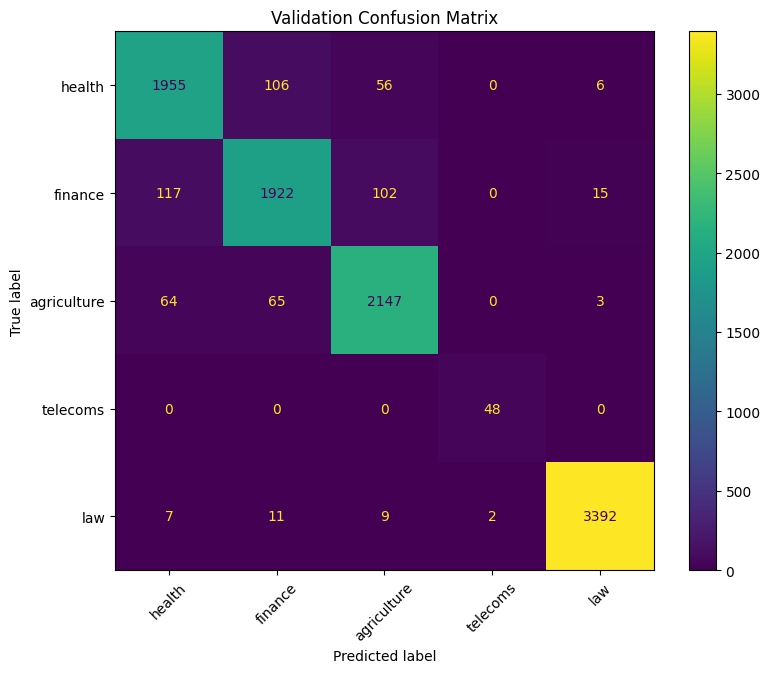

In [22]:
labels = [
    "health",
    "finance",
    "agriculture",
    "telecoms",
    "law"
]

cm = confusion_matrix(
    y_val,
    val_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Validation Confusion Matrix")
plt.show()

## Step 13 — Predict your human Gold Test

In [23]:
gold["Classifier"] = model.predict(
    gold["raw_text"].astype(str)
)

gold_probs = model.predict_proba(
    gold["raw_text"].astype(str)
)

gold["confidence"] = gold_probs.max(axis=1)

display(
    gold[
        [
            "sample_id",
            "raw_text",
            "label",
            "Classifier",
            "confidence"
        ]
    ].head(20)
)

,sample_id,raw_text,label,Classifier,confidence
0,S0001,Iri ni itsinda ry'abaganga aho bari muri opera...,health,health,0.977551
1,S0002,(i) ubusobanuro ku by'ingenzi biranga serivisi...,law,law,0.954890
2,S0003,"Abantu babiri bambaye imyenda y'imyitozo, umwe...",health,health,0.976064
3,S0004,Ibihingwa ngandubukungu n'ibihingwa nganduraru...,agriculture,agriculture,0.990412
4,S0005,"Ubucuruzi icuruzwamo ikinyobwa cy'amata, umucu...",finance,finance,0.985329
5,S0006,Imiterere y'inyandiko zishyirwa kuri izo nyand...,law,law,0.993909
6,S0007,Kwakira abaje bakugana vuba utabatindije bitum...,others,finance,0.564537
7,S0008,Abantu benshi bahagaze bambaye imyambaro iri m...,others,health,0.732963
8,S0009,Ingingo ya 165: uko inzego zifite ububasha mu ...,law,law,0.984772
9,S0010,"Kuri uyu wa Gatatu tariki 9 Kanama 2017, ibiny...",telecoms,telecoms,0.978040


## Step 14 — Evaluate against the human labels

In [24]:
gold_5 = gold[
    gold["label"] != "others"
].copy()

print(
    "Gold 5-domain records:",
    len(gold_5)
)

gold_accuracy = accuracy_score(
    gold_5["label"],
    gold_5["Classifier"]
)

gold_macro_f1 = f1_score(
    gold_5["label"],
    gold_5["Classifier"],
    average="macro"
)

print(
    "Human Gold Accuracy:",
    round(gold_accuracy, 4)
)

print(
    "Human Gold Macro F1:",
    round(gold_macro_f1, 4)
)

print("\nGold Test Classification Report:\n")

print(
    classification_report(
        gold_5["label"],
        gold_5["Classifier"],
        digits=4
    )
)

Gold 5-domain records: 476
Human Gold Accuracy: 0.8697
Human Gold Macro F1: 0.804

Gold Test Classification Report:

              precision    recall  f1-score   support

 agriculture     0.8158    0.9118    0.8611       102
     finance     0.7976    0.8171    0.8072        82
      health     0.8488    0.7526    0.7978        97
         law     0.9402    0.9830    0.9611       176
    telecoms     1.0000    0.4211    0.5926        19

    accuracy                         0.8697       476
   macro avg     0.8805    0.7771    0.8040       476
weighted avg     0.8728    0.8697    0.8652       476



## Step 15 — Examine others

In [25]:
gold_others = gold[
    gold["label"] == "others"
].copy()

print(
    "Human OTHER records:",
    len(gold_others)
)

print("\nWhat the model predicted for OTHER texts:")

print(
    gold_others["Classifier"]
    .value_counts()
)

print(
    "\nAverage confidence on OTHER:",
    round(
        gold_others["confidence"].mean(),
        4
    )
)

Human OTHER records: 100

What the model predicted for OTHER texts:
Classifier
health         41
finance        32
law            16
agriculture    10
telecoms        1
Name: count, dtype: int64

Average confidence on OTHER: 0.7932


# Compare confidence 

In [26]:
print(
    "Average confidence on 5-domain examples:",
    round(
        gold_5["confidence"].mean(),
        4
    )
)

print(
    "Average confidence on OTHER examples:",
    round(
        gold_others["confidence"].mean(),
        4
    )
)

Average confidence on 5-domain examples: 0.9152
Average confidence on OTHER examples: 0.7932


In [27]:
gold.to_excel(
    "/kaggle/working/Gold_Test_with_Classifier_Predictions.xlsx",
    index=False
)

joblib.dump(
    model,
    "/kaggle/working/kinyarwanda_domain_classifier.joblib"
)

print("Results and model saved.")

Results and model saved.


## Generate all result files and a readable report

In [28]:
# FINAL REPORT + RESULT FILES


import os
import json
import platform
import sklearn
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

OUTPUT_DIR = "/kaggle/working/kinyarwanda_classifier_final"

os.makedirs(f"{OUTPUT_DIR}/model", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/data", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/results", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/documentation", exist_ok=True)

# ------------------------------------------------------------
# 1. Save trained model
# ------------------------------------------------------------

MODEL_PATH = f"{OUTPUT_DIR}/model/kinyarwanda_domain_classifier.joblib"

joblib.dump(model, MODEL_PATH)


# ------------------------------------------------------------
# 2. Save Gold Test with classifier predictions
# ------------------------------------------------------------

GOLD_PRED_PATH = (
    f"{OUTPUT_DIR}/results/"
    "Gold_Test_with_Classifier_Predictions.xlsx"
)

gold.to_excel(
    GOLD_PRED_PATH,
    index=False
)


# ------------------------------------------------------------
# 3. Save copies of original input data
# ------------------------------------------------------------

corpus.to_csv(
    f"{OUTPUT_DIR}/data/kinyarwanda_multidomain_candidates.csv",
    index=False
)

gold_original = pd.read_excel(GOLD_PATH)

gold_original.to_excel(
    f"{OUTPUT_DIR}/data/Gold_Test_sample.xlsx",
    index=False
)


# ------------------------------------------------------------
# 4. Overall metrics table
# ------------------------------------------------------------

validation_n = len(y_val)
gold_n = len(gold_5)
other_n = len(gold_others)

metrics = pd.DataFrame([
    {
        "Evaluation": "Internal Validation",
        "Samples": validation_n,
        "Accuracy": val_accuracy,
        "Macro_F1": val_macro_f1
    },
    {
        "Evaluation": "Human Gold Test (5 domains)",
        "Samples": gold_n,
        "Accuracy": gold_accuracy,
        "Macro_F1": gold_macro_f1
    }
])

metrics.to_csv(
    f"{OUTPUT_DIR}/results/metrics.csv",
    index=False
)

display(
    metrics.style.format({
        "Accuracy": "{:.2%}",
        "Macro_F1": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 5. Per-class reports
# ------------------------------------------------------------

val_report = pd.DataFrame(
    classification_report(
        y_val,
        val_pred,
        output_dict=True,
        zero_division=0
    )
).T

gold_report = pd.DataFrame(
    classification_report(
        gold_5["label"],
        gold_5["Classifier"],
        output_dict=True,
        zero_division=0
    )
).T

val_report.to_csv(
    f"{OUTPUT_DIR}/results/"
    "validation_classification_report.csv"
)

gold_report.to_csv(
    f"{OUTPUT_DIR}/results/"
    "gold_test_classification_report.csv"
)


# ------------------------------------------------------------
# 6. Save validation confusion matrix
# ------------------------------------------------------------

class_labels = [
    "health",
    "finance",
    "agriculture",
    "telecoms",
    "law"
]

val_cm = confusion_matrix(
    y_val,
    val_pred,
    labels=class_labels
)

fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay(
    confusion_matrix=val_cm,
    display_labels=class_labels
).plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Validation Confusion Matrix")
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/results/"
    "validation_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------------------------
# 7. Save Gold Test confusion matrix
# ------------------------------------------------------------

gold_cm = confusion_matrix(
    gold_5["label"],
    gold_5["Classifier"],
    labels=class_labels
)

fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay(
    confusion_matrix=gold_cm,
    display_labels=class_labels
).plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Human Gold Test Confusion Matrix")
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/results/"
    "gold_test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------------------------
# 8. Save Gold Test disagreements
# ------------------------------------------------------------

misclassified = gold_5[
    gold_5["label"] != gold_5["Classifier"]
].copy()

misclassified.to_csv(
    f"{OUTPUT_DIR}/results/"
    "gold_test_misclassifications.csv",
    index=False
)


# ------------------------------------------------------------
# 9. Save OTHER analysis
# ------------------------------------------------------------

other_distribution = (
    gold_others["Classifier"]
    .value_counts()
    .rename_axis("Predicted_domain")
    .reset_index(name="Count")
)

other_distribution["Percentage"] = (
    other_distribution["Count"] /
    len(gold_others) * 100
)

other_distribution.to_csv(
    f"{OUTPUT_DIR}/results/"
    "others_prediction_distribution.csv",
    index=False
)


# ------------------------------------------------------------
# 10. Prepare readable tables for Markdown report
# ------------------------------------------------------------

def report_table(df):
    return df.to_markdown(index=False)


overall_table = pd.DataFrame([
    {
        "Evaluation": "Internal validation",
        "Samples": len(y_val),
        "Accuracy": f"{val_accuracy:.2%}",
        "Macro F1": f"{val_macro_f1:.4f}"
    },
    {
        "Evaluation": "Human Gold Test (5 domains)",
        "Samples": len(gold_5),
        "Accuracy": f"{gold_accuracy:.2%}",
        "Macro F1": f"{gold_macro_f1:.4f}"
    }
])


val_classes = val_report.loc[
    class_labels,
    ["precision", "recall", "f1-score", "support"]
].reset_index()

val_classes.columns = [
    "Domain",
    "Precision",
    "Recall",
    "F1",
    "Support"
]

for c in ["Precision", "Recall", "F1"]:
    val_classes[c] = val_classes[c].map(
        lambda x: f"{x:.4f}"
    )

val_classes["Support"] = (
    val_classes["Support"]
    .astype(int)
)


gold_classes = gold_report.loc[
    class_labels,
    ["precision", "recall", "f1-score", "support"]
].reset_index()

gold_classes.columns = [
    "Domain",
    "Precision",
    "Recall",
    "F1",
    "Support"
]

for c in ["Precision", "Recall", "F1"]:
    gold_classes[c] = gold_classes[c].map(
        lambda x: f"{x:.4f}"
    )

gold_classes["Support"] = (
    gold_classes["Support"]
    .astype(int)
)


other_table = other_distribution.copy()

other_table["Percentage"] = (
    other_table["Percentage"]
    .map(lambda x: f"{x:.1f}%")
)


# ------------------------------------------------------------
# 11. Generate interpretation automatically
# ------------------------------------------------------------

accuracy_gap = (
    val_accuracy - gold_accuracy
) * 100

avg_conf_5 = gold_5["confidence"].mean()
avg_conf_other = gold_others["confidence"].mean()

report = f"""
# Kinyarwanda Multidomain Classifier Report

## 1. Experiment Overview

A TF-IDF + Logistic Regression classifier was trained to classify
Kinyarwanda text into five domains:

- Agriculture
- Finance
- Health
- Law
- Telecoms

The manually annotated Gold Test set was excluded from both training
and internal validation to prevent test-set leakage.

The Gold Test also contains an `others` category. Because `others`
was not available as a training class, those examples are analyzed
separately rather than included in the five-class accuracy score.

---

## 2. Overall Performance

{report_table(overall_table)}

### Interpretation

The classifier achieved **{val_accuracy:.2%} accuracy** and a
**Macro F1-score of {val_macro_f1:.4f}** on the internal validation
set. This indicates strong performance in reproducing the domain
labels contained in the collected corpus.

On the independently human-annotated Gold Test, the classifier
achieved **{gold_accuracy:.2%} accuracy** and a **Macro F1-score of
{gold_macro_f1:.4f}** for the five target domains.

The Gold Test accuracy is **{accuracy_gap:.2f} percentage points
lower** than the internal validation accuracy. This difference is
important because the validation set reflects the original corpus
labels, whereas the Gold Test reflects independent human judgments.

The drop therefore suggests that reproducing the original corpus
labels is easier than reproducing human domain judgments. It may
also indicate ambiguity in some source labels and/or that the model
has learned source-specific writing patterns in addition to domain
semantics.

---

## 3. Internal Validation Performance by Domain

{report_table(val_classes)}

The validation results are strong across all five domains.

**Law** obtained the highest validation F1-score
({val_report.loc["law", "f1-score"]:.4f}).

**Telecoms** also obtained a very high validation F1-score
({val_report.loc["telecoms", "f1-score"]:.4f}), but this value should
be interpreted carefully because the validation set contains only
{int(val_report.loc["telecoms", "support"])} Telecoms examples,
substantially fewer than the other domains.

---

## 4. Human Gold Test Performance by Domain

{report_table(gold_classes)}

The Human Gold Test provides a more demanding evaluation because its
labels were assigned manually and independently from the original
dataset labels.

**Law** remained the strongest Gold Test class, with an F1-score of
{gold_report.loc["law", "f1-score"]:.4f}.

Agriculture, Finance, and Health achieved F1-scores of
{gold_report.loc["agriculture", "f1-score"]:.4f},
{gold_report.loc["finance", "f1-score"]:.4f}, and
{gold_report.loc["health", "f1-score"]:.4f}, respectively.

**Telecoms was the most difficult Gold Test class.** Its precision was
{gold_report.loc["telecoms", "precision"]:.4f}, while recall was only
{gold_report.loc["telecoms", "recall"]:.4f}, producing an F1-score of
{gold_report.loc["telecoms", "f1-score"]:.4f}.

This means that when the classifier predicted Telecoms it was usually
correct, but it failed to identify a substantial proportion of the
texts that the human annotator considered Telecoms. The small Gold
Test support of {int(gold_report.loc["telecoms", "support"])} examples
should also be considered when interpreting this result.

---

## 5. Analysis of the `others` Category

The Gold Test contains **{len(gold_others)}** examples manually
identified as `others`.

Because the classifier was trained only on the five target domains,
it was forced to assign each of these texts to one of those domains.

{report_table(other_table)}

The average classifier confidence was:

| Group | Average confidence |
|---|---:|
| Five target domains | {avg_conf_5:.4f} |
| Human-labelled `others` | {avg_conf_other:.4f} |

Confidence was lower for `others` than for examples belonging to the
five target domains. This suggests that confidence may contain useful
information for detecting ambiguous or out-of-domain texts.

However, the average confidence on `others`
({avg_conf_other:.4f}) is still relatively high. Therefore, a simple
confidence threshold should not automatically be treated as a reliable
`others` detector without further validation.

---

## 6. Key Findings

| Finding | Interpretation |
|---|---|
| Validation accuracy | {val_accuracy:.2%} — strong reproduction of the original corpus labels |
| Validation Macro F1 | {val_macro_f1:.4f} — strong performance across the five domains |
| Human Gold accuracy | {gold_accuracy:.2%} — lower than internal validation, showing that human evaluation is more challenging |
| Human Gold Macro F1 | {gold_macro_f1:.4f} — domain performance is less uniform on manually reviewed data |
| Accuracy gap | {accuracy_gap:.2f} percentage points between validation and Gold Test |
| Strongest Gold domain | Law |
| Most difficult Gold domain | Telecoms |
| Human-labelled `others` | {len(gold_others)} examples |
| Confidence on 5 domains | {avg_conf_5:.4f} |
| Confidence on `others` | {avg_conf_other:.4f} |

---

## 7. Conclusion

The classifier provides a strong baseline for automatic domain
classification of the collected Kinyarwanda corpus.

Its high internal validation performance shows that TF-IDF features
combined with Logistic Regression can effectively learn the five
domain labels in the collected data.

The lower performance against independently reviewed human labels,
however, demonstrates why manual validation is important. The
difference between corpus-label performance and Gold Test performance
suggests that some texts are semantically ambiguous or may not align
perfectly with the domain assigned by their original source.

The `others` analysis further shows that forcing every text into one
of five domains can produce confident predictions even for texts that
a human reviewer considers outside the target domains. Future work
could therefore investigate explicit abstention, confidence
calibration, or a separately trained `others` class using additional
independently labelled data.
"""

REPORT_PATH = (
    f"{OUTPUT_DIR}/results/classifier_report.md"
)

with open(
    REPORT_PATH,
    "w",
    encoding="utf-8"
) as f:
    f.write(report)

print("✓ Model saved")
print("✓ Predictions saved")
print("✓ Metrics saved")
print("✓ Classification reports saved")
print("✓ Confusion matrices saved")
print("✓ Misclassifications saved")
print("✓ OTHER analysis saved")
print("✓ Full Markdown report saved")

,Evaluation,Samples,Accuracy,Macro_F1
0,Internal Validation,10027,94.39%,0.9451
1,Human Gold Test (5 domains),476,86.97%,0.8040


✓ Model saved
✓ Predictions saved
✓ Metrics saved
✓ Classification reports saved
✓ Confusion matrices saved
✓ Misclassifications saved
✓ OTHER analysis saved
✓ Full Markdown report saved


## Save model/training metadata

In [29]:
# SAVE TRAINING AND ENVIRONMENT INFORMATION

classifier = model.named_steps["classifier"]

metadata = {
    "task": "Kinyarwanda multidomain text classification",

    "model": "TF-IDF + Logistic Regression",

    "classes": list(model.classes_),

    "features": {
        "word_tfidf": {
            "ngram_range": [1, 2],
            "min_df": 2,
            "max_df": 0.98,
            "sublinear_tf": True
        },

        "character_tfidf": {
            "analyzer": "char_wb",
            "ngram_range": [3, 5],
            "min_df": 2,
            "sublinear_tf": True
        }
    },

    "classifier": {
        "type": "LogisticRegression",
        "class_weight": "balanced",
        "max_iter": 2000,
        "actual_solver_iterations":
            classifier.n_iter_.tolist(),
        "random_state": 42
    },

    "data_split": {
        "training_fraction": 0.80,
        "validation_fraction": 0.20,
        "stratified": True,
        "gold_test_excluded_from_training": True
    },

    "results": {
        "validation_accuracy":
            float(val_accuracy),

        "validation_macro_f1":
            float(val_macro_f1),

        "gold_5_domain_accuracy":
            float(gold_accuracy),

        "gold_5_domain_macro_f1":
            float(gold_macro_f1),

        "gold_5_domain_samples":
            int(len(gold_5)),

        "gold_others_samples":
            int(len(gold_others)),

        "average_confidence_5_domains":
            float(avg_conf_5),

        "average_confidence_others":
            float(avg_conf_other)
    }
}

with open(
    f"{OUTPUT_DIR}/documentation/model_metadata.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metadata,
        f,
        indent=4,
        ensure_ascii=False
    )


environment = f"""
Python: {platform.python_version()}
pandas: {pd.__version__}
scikit-learn: {sklearn.__version__}
joblib: {joblib.__version__}
"""

with open(
    f"{OUTPUT_DIR}/documentation/environment_versions.txt",
    "w"
) as f:

    f.write(environment.strip())


print(json.dumps(metadata, indent=2))

{
  "task": "Kinyarwanda multidomain text classification",
  "model": "TF-IDF + Logistic Regression",
  "classes": [
    "agriculture",
    "finance",
    "health",
    "law",
    "telecoms"
  ],
  "features": {
    "word_tfidf": {
      "ngram_range": [
        1,
        2
      ],
      "min_df": 2,
      "max_df": 0.98,
      "sublinear_tf": true
    },
    "character_tfidf": {
      "analyzer": "char_wb",
      "ngram_range": [
        3,
        5
      ],
      "min_df": 2,
      "sublinear_tf": true
    }
  },
  "classifier": {
    "type": "LogisticRegression",
    "class_weight": "balanced",
    "max_iter": 2000,
    "actual_solver_iterations": [
      77
    ],
    "random_state": 42
  },
  "data_split": {
    "training_fraction": 0.8,
    "validation_fraction": 0.2,
    "stratified": true,
    "gold_test_excluded_from_training": true
  },
  "results": {
    "validation_accuracy": 0.943851600678169,
    "validation_macro_f1": 0.9451275427302207,
    "gold_5_domain_accuracy": 

In [30]:
# ============================================================
# CREATE README + FINAL ZIP
# ============================================================

import shutil
from IPython.display import FileLink, display

readme = """
# Kinyarwanda Multidomain Domain Classifier

This package contains the files required to preserve the
Kinyarwanda domain-classification experiment.

## Folder Structure

### model/
- `kinyarwanda_domain_classifier.joblib`
  Trained TF-IDF + Logistic Regression pipeline.

### data/
- `kinyarwanda_multidomain_candidates.csv`
  Multidomain corpus used for model development.
- `Gold_Test_sample.xlsx`
  Manually annotated Gold Test data.

### results/
- `Gold_Test_with_Classifier_Predictions.xlsx`
- `metrics.csv`
- `validation_classification_report.csv`
- `gold_test_classification_report.csv`
- `validation_confusion_matrix.png`
- `gold_test_confusion_matrix.png`
- `gold_test_misclassifications.csv`
- `others_prediction_distribution.csv`
- `classifier_report.md`

### documentation/
- `model_metadata.json`
- `environment_versions.txt`

## Important

The manually annotated Gold Test examples were removed from the
training corpus before model training and internal validation.

The model was trained on five classes:
Health, Finance, Agriculture, Telecoms, and Law.

The human Gold Test additionally contains an `others` label.
Because `others` was not included during training, it is analyzed
separately rather than treated as a sixth model class.
"""

with open(
    f"{OUTPUT_DIR}/README.md",
    "w",
    encoding="utf-8"
) as f:

    f.write(readme.strip())


ZIP_BASE = "/kaggle/working/kinyarwanda_classifier_final"

shutil.make_archive(
    ZIP_BASE,
    "zip",
    root_dir="/kaggle/working",
    base_dir="kinyarwanda_classifier_final"
)

ZIP_PATH = ZIP_BASE + ".zip"

print("========================================")
print("FINAL PACKAGE CREATED")
print("========================================")
print(ZIP_PATH)

display(FileLink(ZIP_PATH))

FINAL PACKAGE CREATED
/kaggle/working/kinyarwanda_classifier_final.zip


/kaggle/working/kinyarwanda_classifier_final.zip